<a href="https://colab.research.google.com/github/apmalani/cs-172b-project/blob/main/CIFAR_10_RSB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BalancedCNN(nn.Module):
    def __init__(self):
        super(BalancedCNN, self).__init__()

        # 1. Input Layer: Change in_channels from 1 to 3
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # 2. The Bottleneck: Squeezing to 16 (instead of 8 for better capacity)
        self.conv3 = nn.Conv2d(64, 16, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)

        # 3. Recovery Phase
        self.conv4 = nn.Conv2d(16, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.maxpool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()

        # 4. Calculation for Linear Layer:
        # CIFAR-10 is 32x32. After two MaxPool(2x2) layers, size is 8x8.
        # 64 channels * 8 * 8 = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # Block 1: 32x32 -> 16x16
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # Block 2: 16x16 -> 16x16
        x = self.relu(self.bn2(self.conv2(x)))

        # Bottleneck: 16x16 -> 16x16
        x = self.relu(self.bn3(self.conv3(x)))

        # Block 3: 16x16 -> 8x8
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.maxpool(x)
        x = self.dropout(x)

        # Flatten and Classify
        x = x.view(x.size(0), -1) # Dynamic flattening
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

In [29]:
class RSB_Loss_CNN(nn.Module):
    def __init__(self, alpha=0.01, beta=0.005):
        super().__init__()
        self.alpha = alpha
        self.beta = beta

    def forward(self, outputs, targets, model):
        # 1. Classification Loss
        ce_loss = F.nll_loss(outputs, targets)

        # 2. Extract weights of Conv and Linear layers
        weights = [p for p in model.parameters() if len(p.shape) > 1]
        norms = [torch.norm(w)**2 for w in weights]

        # 3. RSB Regularization
        # Anchor the output layer
        reg = self.alpha * norms[-1]

        # Chain the balance from input to output
        for i in range(len(norms) - 1):
            reg += self.beta * (norms[i] - norms[i+1])**2

        return ce_loss + reg

In [30]:
def get_network_balance(model):
    """Calculates the mean squared difference between adjacent weight layer norms."""
    with torch.no_grad():
        # Get weight matrices (ignoring biases for balance calculation)
        weights = [p for p in model.parameters() if len(p.shape) > 1]
        norms = [torch.sum(w**2) for w in weights]

        diffs = []
        for i in range(len(norms) - 1):
            # (Layer_k_norm - Layer_k+1_norm)^2
            diffs.append((norms[i] - norms[i+1])**2)

        return torch.mean(torch.stack(diffs)).item(), sum(n.item() for n in norms)

In [31]:
# @title
def get_neuron_stats(model):
    total_neuron_imbalance = 0.0
    # Use modules to be safer with Layer-to-Layer order
    weights = [m.weight for m in model.modules() if isinstance(m, (nn.Conv2d, nn.Linear))]

    for i in range(len(weights) - 1):
        w_curr = weights[i]
        w_next = weights[i+1]

        # 1. Incoming (Rows of current)
        if w_curr.dim() == 4:
            in_energy = torch.sum(w_curr**2, dim=(1, 2, 3))
        else:
            in_energy = torch.sum(w_curr**2, dim=1)

        # 2. Outgoing (Cols of next)
        if w_next.dim() == 4:
            out_energy = torch.sum(w_next**2, dim=(0, 2, 3))
        else:
            out_energy = torch.sum(w_next**2, dim=0)

        # 3. Handling CIFAR/Spatial Flattening
        if in_energy.size(0) != out_energy.size(0):
            # Calculate how many spatial pixels/features belong to one channel
            if out_energy.size(0) % in_energy.size(0) == 0:
                factor = out_energy.size(0) // in_energy.size(0)
                out_energy = out_energy.view(in_energy.size(0), factor).sum(dim=1)
            else:
                # Fallback: if they don't align (rare), take the mean to compare scale
                # This prevents the IndexError you saw earlier
                continue

        # 4. Compute Sum of Absolute Differences
        neuron_diffs = torch.abs(in_energy - out_energy)
        total_neuron_imbalance += torch.sum(neuron_diffs).item()

    return total_neuron_imbalance

In [32]:
def evaluate_model(model, loader, device='cuda'):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation for speed and memory
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    return 100 * correct / total

In [33]:
def get_accuracy(outputs, targets):
    pred = outputs.argmax(dim=1, keepdim=True)
    correct = pred.eq(targets.view_as(pred)).sum().item()
    return correct / targets.size(0)

In [34]:
alpha = 0.001
beta = 0.01
l2_alpha = alpha
epochs = 30
learn_rate = 0.01
batch_size = 128
collection_rate = 50
momentum = 0.9

In [35]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
# @title
# 1. Use the same normalization as the training set
# (Crucial: the model expects the same mean/std it was trained on)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. Load the CIFAR-10 test split
test_set = datasets.CIFAR10(
    root='./data',
    train=False,         # This fetches the 10,000 test images
    download=True,
    transform=test_transform
)

# 3. Create the DataLoader
# shuffle=False is standard for testing to keep results consistent
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2        # Optional: speeds up data loading
)

In [36]:
# @title
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch

# 1. Updated Transforms for CIFAR-10
# Standard CIFAR-10 normalization values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# 2. Updated Dataset to CIFAR-10
train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# --- IMPORTANT ---
# Ensure your BalancedCNN class __init__ handles in_channels=3
# instead of in_channels=1.
# -----------------

# Initialize Models (Identical Seeds)
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

rsb_model = BalancedCNN().to(device)
u_model = BalancedCNN().to(device)
u_model.load_state_dict(rsb_model.state_dict())
l2_model = BalancedCNN().to(device)
l2_model.load_state_dict(rsb_model.state_dict())

# Optimizers (You can use adam or SGD both work)
# rsb_opt = torch.optim.Adam(rsb_model.parameters(), lr=0.001)
# u_opt = torch.optim.Adam(u_model.parameters(), lr=0.001)
rsb_opt = torch.optim.SGD(rsb_model.parameters(), lr=learn_rate, momentum=momentum)
u_opt = torch.optim.SGD(u_model.parameters(), lr=learn_rate, momentum=momentum)
l2_opt = torch.optim.SGD(l2_model.parameters(), lr=learn_rate, weight_decay=0, momentum=momentum)
scheduler_b = torch.optim.lr_scheduler.StepLR(rsb_opt, step_size=10, gamma=0.5)

# Criteria
rsb_crit = RSB_Loss_CNN(alpha=alpha, beta=beta)
u_crit = nn.NLLLoss() # Standard baseline
l2_crit = nn.NLLLoss()

# Training Loop
history = []

# Training Loop
for epoch in range(1, epochs):
    rsb_model.train(); u_model.train()

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to('cuda'), target.to('cuda')

        # --- RSB Model Step ---
        rsb_opt.zero_grad()
        output_b = rsb_model(data)
        loss_b = rsb_crit(output_b, target, rsb_model)
        loss_b.backward()
        rsb_opt.step()

        # --- Unbalanced Model Step ---
        u_opt.zero_grad()
        output_u = u_model(data)
        loss_u = u_crit(output_u, target)
        loss_u.backward()
        u_opt.step()
       # --- L2 Model Step (Global Regularization) ---
        l2_opt.zero_grad()
        output_l2 = l2_model(data)
        loss_l2_data = l2_crit(output_l2, target)

        # Apply alpha to ALL weight matrices (matching your RSB alpha scaling)
        l2_penalty = 0
        for name, param in l2_model.named_parameters():
            if 'weight' in name: # Exclude biases to keep it scientific
                l2_penalty += l2_alpha * torch.sum(param**2)

        loss_l2 = loss_l2_data + l2_penalty
        loss_l2.backward()
        l2_opt.step()

        if batch_idx % collection_rate == 0:
            # 1. Calculate Accuracies
            acc_b = get_accuracy(output_b, target)
            acc_u = get_accuracy(output_u, target)
            acc_l2 = get_accuracy(output_l2, target)

            # 2. Track the Balance
            b_val, b_norm = get_network_balance(rsb_model)
            u_val, u_norm = get_network_balance(u_model)
            l2_val, l2_norm = get_network_balance(l2_model)
            b_neuron_bal = get_neuron_stats(rsb_model)
            u_neuron_bal = get_neuron_stats(u_model)
            l2_neuron_bal = get_neuron_stats(l2_model)
            rsb_test_acc = evaluate_model(rsb_model, test_loader)
            u_test_acc   = evaluate_model(u_model, test_loader)
            l2_test_acc  = evaluate_model(l2_model, test_loader)
            print(f"Epoch {epoch} [{batch_idx*len(data):5d}/{len(train_loader.dataset)}]")
            print(f"  > RSB:   Loss: {loss_b.item():.4f} | Acc: {acc_b:6.2%} | Test Acc: {rsb_test_acc:.2f}% | Balance: {b_val:.6f} | Norm: {b_norm:.6f} | Neuron Bal: {b_neuron_bal:.4f}")
            print(f"  > UNREG: Loss: {loss_u.item():.4f} | Acc: {acc_u:6.2%} | Test Acc: {u_test_acc:.2f}% | Balance: {u_val:.6f} | Norm: {u_norm:.6f} | Neuron Bal: {u_neuron_bal:.4f}")
            print(f"  > L2: Loss: {loss_l2.item():.4f} | Acc: {acc_l2:6.2%} | Test Acc: {l2_test_acc:.2f}% | Balance: {l2_val:.6f} | Norm: {l2_norm:.6f} | Neuron Bal: {l2_neuron_bal:.4f}")
            print("-" * 65)

            # Append to history for the vertical column plots later
            history.append({
                'epoch': epoch + batch_idx/len(train_loader),
                'b_acc': acc_b, 'u_acc': acc_u,
                'b_bal': b_val, 'u_bal': u_val,
                'b_norm': b_norm, 'u_norm': u_norm,
                'l2_bal': l2_val,
                'l2_acc': acc_l2,
                'l2_norm': l2_norm,
                'b_neuron_bal': b_neuron_bal.item() if torch.is_tensor(b_neuron_bal) else b_neuron_bal,
                'u_neuron_bal': u_neuron_bal.item() if torch.is_tensor(u_neuron_bal) else u_neuron_bal,
                'l2_neuron_bal': l2_neuron_bal.item() if torch.is_tensor(l2_neuron_bal) else l2_neuron_bal,
                'rsb_test_acc': rsb_test_acc,
                'u_test_acc': u_test_acc,
                'l2_test_acc': l2_test_acc
            })

Epoch 1 [    0/50000]
  > RSB:   Loss: 116.7682 | Acc: 10.16% | Test Acc: 9.73% | Balance: 1735.142212 | Norm: 138.790947 | Neuron Bal: 167.6914
  > UNREG: Loss: 2.3445 | Acc: 13.28% | Test Acc: 9.73% | Balance: 2287.904785 | Norm: 147.637992 | Neuron Bal: 188.5222
  > L2: Loss: 2.6553 | Acc:  8.59% | Test Acc: 9.88% | Balance: 2287.722900 | Norm: 147.632561 | Neuron Bal: 188.5147
-----------------------------------------------------------------
Epoch 1 [ 6400/50000]
  > RSB:   Loss: 2.2994 | Acc: 24.22% | Test Acc: 27.90% | Balance: 3.134134 | Norm: 56.208051 | Neuron Bal: 8.6377
  > UNREG: Loss: 2.2339 | Acc: 18.75% | Test Acc: 18.81% | Balance: 2297.274658 | Norm: 148.214723 | Neuron Bal: 188.8370
  > L2: Loss: 2.5599 | Acc: 16.41% | Test Acc: 17.67% | Balance: 2220.637451 | Norm: 145.734248 | Neuron Bal: 185.6667
-----------------------------------------------------------------
Epoch 1 [12800/50000]
  > RSB:   Loss: 1.8925 | Acc: 33.59% | Test Acc: 33.40% | Balance: 0.026708 | Norm

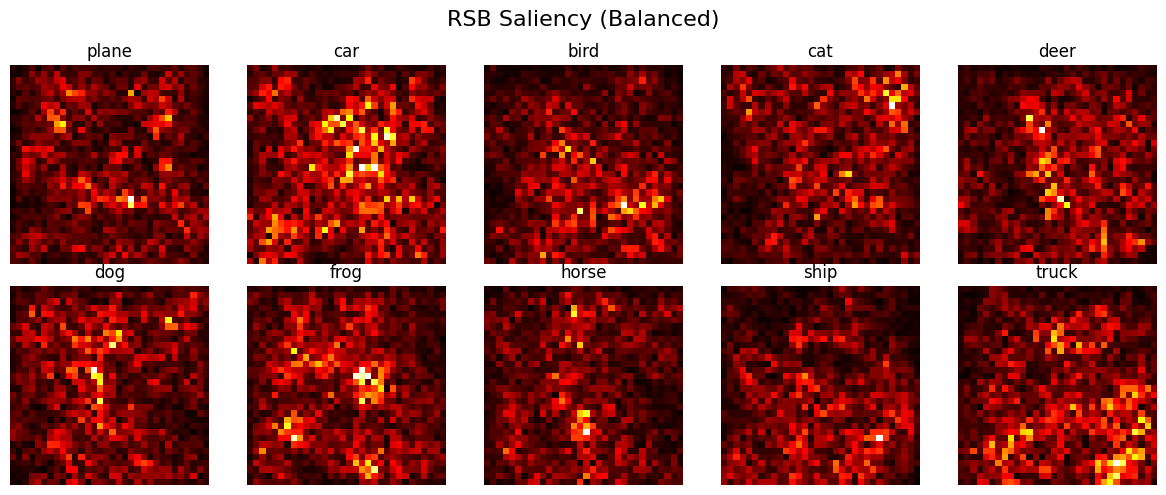

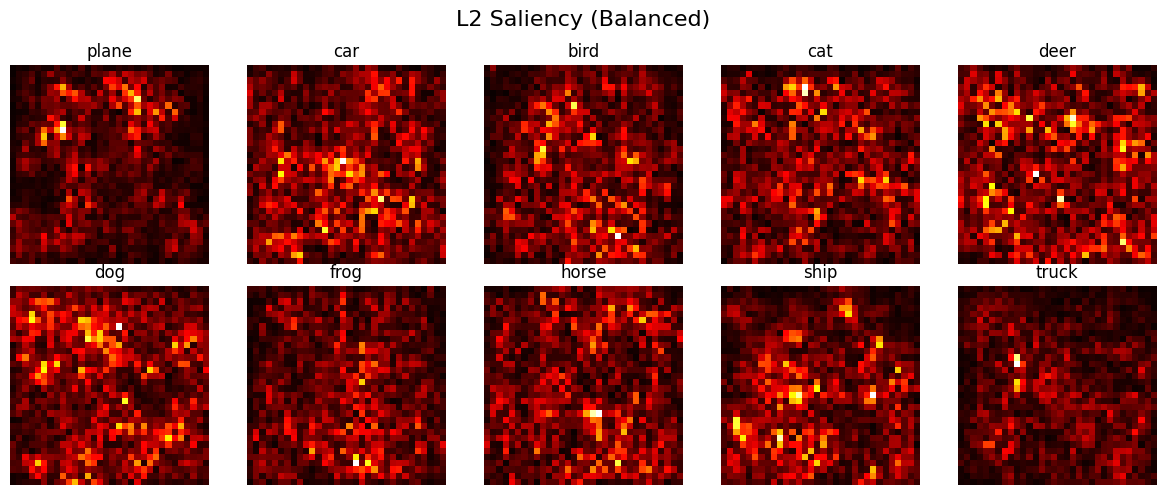

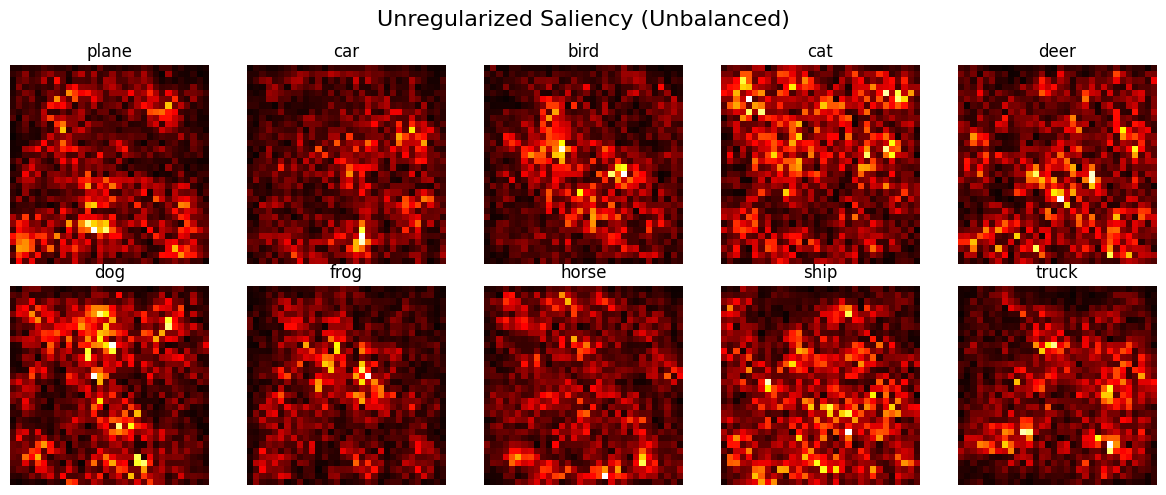

In [40]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# 1. Update test_loader for CIFAR-10
test_loader = DataLoader(
    datasets.CIFAR10('./data', train=False, download=True, transform=transform),
    batch_size=64, shuffle=False
)

# CIFAR-10 class names for better titles
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def visualize_saliency(model, title, device='cuda'):
    model.eval()
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=16)

    # Find one example of each class
    examples = {}
    for data, target in test_loader:
        for i in range(len(target)):
            label = target[i].item()
            if label not in examples and len(examples) < 10:
                examples[label] = data[i].unsqueeze(0).to(device)
        if len(examples) >= 10: break

    for i in range(10):
        img = examples[i]
        img.requires_grad_()

        output = model(img)
        # Handle log_softmax vs raw logits: score is the target class output
        score = output[0, i]

        model.zero_grad() # Clean gradients before backward
        score.backward()

        # 2. Saliency for RGB: Take the max across the channel dimension (dim=1)
        # img.grad.data is [1, 3, 32, 32]
        saliency, _ = torch.max(img.grad.data.abs(), dim=1)
        saliency = saliency.reshape(32, 32).cpu().numpy()

        ax = axes[i//5, i%5]

        # 3. Use 'viridis' or 'hot' for the heatmap
        im = ax.imshow(saliency, cmap='hot')
        ax.set_title(f"{classes[i]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Run the comparison
visualize_saliency(rsb_model, title="RSB Saliency (Balanced)")
visualize_saliency(l2_model, title="L2 Saliency (Balanced)")
visualize_saliency(u_model, title="Unregularized Saliency (Unbalanced)")

In [41]:
import pandas as pd
df = pd.DataFrame(history)

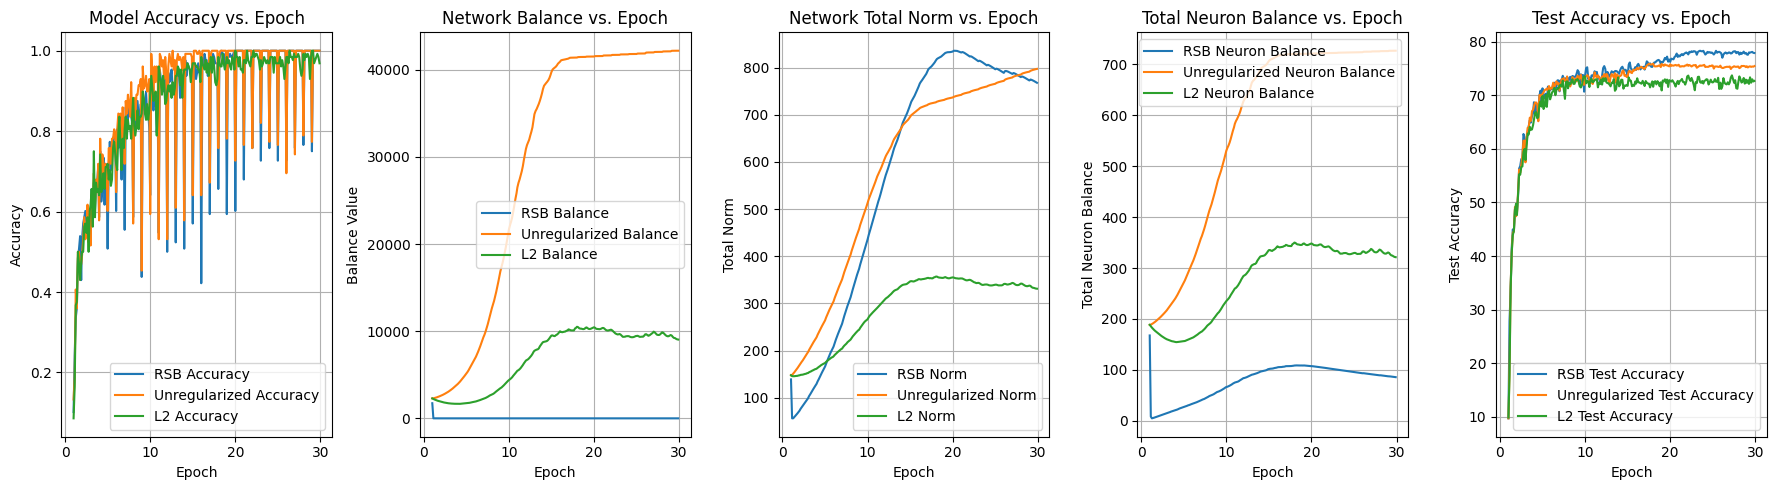

In [45]:
# @title
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5)) # Adjusted figure width for 5 subplots

# Subplot 1: Accuracy
plt.subplot(1, 5, 1)
plt.plot(df['epoch'], df['b_acc'], label='RSB Accuracy')
plt.plot(df['epoch'], df['u_acc'], label='Unregularized Accuracy')
plt.plot(df['epoch'], df['l2_acc'], label='L2 Accuracy')
plt.title('Model Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Subplot 2: Network Balance
plt.subplot(1, 5, 2)
plt.plot(df['epoch'], df['b_bal'], label='RSB Balance')
plt.plot(df['epoch'], df['u_bal'], label='Unregularized Balance')
plt.plot(df['epoch'], df['l2_bal'], label='L2 Balance')
plt.title('Network Balance vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Balance Value')
plt.legend()
plt.grid(True)

# Subplot 3: Network Total Norm
plt.subplot(1, 5, 3) # Changed from (1, 4, 3) to (1, 5, 3)
plt.plot(df['epoch'], df['b_norm'], label='RSB Norm')
plt.plot(df['epoch'], df['u_norm'], label='Unregularized Norm')
plt.plot(df['epoch'], df['l2_norm'], label='L2 Norm')
plt.title('Network Total Norm vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Norm')
plt.legend()
plt.grid(True)

# Subplot 4: Total Neuron Balance
plt.subplot(1, 5, 4) # Changed from (1, 4, 4) to (1, 5, 4)
plt.plot(df['epoch'], df['b_neuron_bal'], label='RSB Neuron Balance') # Changed label for clarity
plt.plot(df['epoch'], df['u_neuron_bal'], label='Unregularized Neuron Balance') # Changed label for clarity
plt.plot(df['epoch'], df['l2_neuron_bal'], label='L2 Neuron Balance') # Changed label for clarity
plt.title('Total Neuron Balance vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Neuron Balance')
plt.legend()
plt.grid(True)

# Subplot 5: Test Accuracy
plt.subplot(1, 5, 5) # Changed from (1, 4, 5) to (1, 5, 5)
plt.plot(df['epoch'], df['rsb_test_acc'], label='RSB Test Accuracy') # Changed column name to match history keys
plt.plot(df['epoch'], df['u_test_acc'], label='Unregularized Test Accuracy') # Changed column name to match history keys
plt.plot(df['epoch'], df['l2_test_acc'], label='L2 Test Accuracy') # Changed column name to match history keys
plt.title('Test Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()